# 1. MC 이론가 재산출 (미래에셋 방식, 무보정) → 학습데이터 완성

`0_data` 가 만든 base(`data/els3_dataset.parquet`, branch·계약·fair)에 **MC 이론가 `mc`** 와 그 입력(`mc_vol1/2/3`, `mc_rho12/13/23`, `mc_r_krw`, `mc_k`) + 인과적 `recent_margin` 을 추가해 학습데이터를 완성하고, 학습 CSV 2종(`ml`/`deeponet`)을 생성한다.

**MC 방식**: 일별 GBM + 촐레스키(180일 역사 상관) + 180일 역사 변동성 + KRW Nelson-Siegel 할인 + q=0 + 일별 KI, **40,000 경로**. 곡선·vol·corr 정의는 공용 `module.features`, 엔진은 `module.mc` (0_data·MC 동일 로직 = DRY).

**캘리브레이션 없음(정본)**: 역사변동성은 내재변동성보다 낮아 MC가 공정가치를 상회한다(특히 저가·고위험 구간). 임의의 vol 프리미엄 `k` 배수 보정을 탐색했으나 **근거·통용성이 약해 기각**하고, 정본은 **무보정(k=1, 순수 180일 역사변동성)** 으로 확정했다(`data/cache/calib_kmap.json` 부재 → `MC.load_kmap()=None`). MC의 저가구간 과대평가 편향은 하이브리드의 인과적 `recent_margin`+stage-2 잔차가 흡수한다. (보정 실험본은 `scratch/backup_derived/` 에 백업.)

> ⚠️ **대량 실행**: 23,151개 × 40k 경로. 단일코어 순차 ≈ 14시간이므로 실제 재산출은 프로세스 병렬 샤드로 수행한다(`python -m module.mc_shards shard k N` / `combine N`). 아래 실행 셀은 `RUN=False` 가드(=병렬 샤드로 이미 채운 `mc` 를 사용). `RUN=True` 는 단일코어 재현용.

In [1]:
import json, bisect
import numpy as np, pandas as pd
from util import file_manager as fm
from module import data, mc as MC

kmap = MC.load_kmap()
print("MC 엔진 | NPATH", MC.NPATH)
print("캘리브레이션 kmap:", kmap if kmap else "(없음 → 미보정 MC)")

MC 엔진 | NPATH 40000
캘리브레이션 kmap: (없음 → 미보정 MC)


In [2]:
# 소량 동작 확인 (base 앞 2개 상품): mc + 적용 배수 k
mk = MC.load_market()
_df = pd.read_parquet(fm.source()).sort_values("isu_ord").reset_index(drop=True)
for _, rw in _df.head(2).iterrows():
    r = MC.price_one(mk, kmap, rw["item"], rw["isu_ord"], float(rw["B"]), float(rw["coupon"]),
                     float(rw["tenor"]), float(rw["sig_eff"]))
    print(f"{rw['item']} -> mc {r[0]:.4f} | k {r[8]:.3f} | fair {rw['fair']:.4f}")

KR6523318519 -> mc 0.9986 | k 1.000 | fair 0.9010
KR6523313510 -> mc 1.0061 | k 1.000 | fair 0.8894


## 전체 재산출 (병렬 샤드) → els3_dataset 갱신

실제 재산출은 프로세스 병렬 샤드로 수행하고(`N`≈CPU-4), 완료 후 `combine` 이 `mc`·MC입력·`recent_margin` 을 `data/els3_dataset.parquet` 에 기록한다. 프로젝트 루트에서(git-bash; 각 샤드는 `OMP_NUM_THREADS=1` 자동 설정):
```bash
N=28
seq 0 $((N-1)) | xargs -P $N -I {} python -m module.mc_shards shard {} $N   # 계산 (샤드별 진행 출력)
python -m module.mc_shards monitor $N     # (선택) 다른 터미널: 전체 진행률 n/23151 · 처리율 · ETA 한 줄
python -m module.mc_shards combine $N
```
**진행상황 표시**: 각 샤드는 200개마다 `shard{k}: n/총 (경과s)` 를 출력하고 동시에 `scratch/mc_progress/` 에 heartbeat 를 남긴다. 다른 터미널에서 `monitor N` 을 띄우면 전 샤드를 합산한 **누적 진행률 · 처리율 · ETA · 완료샤드 수**를 한 줄로 갱신 표시한다(`combine` 이 heartbeat 자동 정리).

샤드 엔진은 공용 `module.mc`(= 소량 검증 셀·`4_MC_pricing` 과 동일). 아래 셀은 `RUN=False` 가드: 병렬 샤드가 이미 `mc` 를 채웠으면 그대로 사용하고, `RUN=True` 이면 단일코어로 재현 계산한다(수 시간).

In [3]:
RUN = False   # False: mc 없으면 캐시된 샤드 JSON 을 combine (수 초). True: 단일코어로 처음부터 재시뮬 (수 시간, JSON 불필요).

from module import mc_shards
df = pd.read_parquet(fm.source()).sort_values("isu_ord").reset_index(drop=True)
has_mc = "mc" in df.columns                            # ① mc 컬럼 존재 여부
shards = sorted(fm.CACHE.glob("mccal_shard_*.json"))   # ② 캐시된 MC 샤드 JSON 존재 여부
print(f"mc 컬럼: {'있음' if has_mc else '없음'} | 캐시 샤드 JSON: {len(shards)}개")

if has_mc:                                             # 이미 mc 있음 → 재계산 생략
    print("→ 재계산 생략 (기존 mc 사용)")
elif RUN:                                              # mc 없음 + 강제: 단일코어 인라인 재시뮬 (JSON 불필요, 수 시간)
    print("→ RUN=True: 단일코어 전체 재시뮬")
    FACE = 10000
    res = np.full((len(df), len(MC.MC_COLS)), np.nan)
    for i, rw in df.iterrows():
        res[i] = MC.price_one(mk, kmap, rw["item"], rw["isu_ord"], float(rw["B"]),
                              float(rw["coupon"]), float(rw["tenor"]), float(rw["sig_eff"]))
        if (i + 1) % 500 == 0:
            print(f"{i+1}/{len(df)}", flush=True)
    for j, cnm in enumerate(MC.MC_COLS):
        df[cnm] = res[:, j].astype("float32")
    df["fair_minus_mc"] = (df["fair"] - df["mc"]).astype("float32")
    df["mc_krw"] = (df["mc"] * FACE).round().astype("float32")
    df["fair_krw"] = (df["fair"] * FACE).round().astype("float32")
    df["fair_minus_mc_krw"] = ((df["fair"] - df["mc"]) * FACE).round().astype("float32")
    o = df["isu_ord"].tolist(); mg = (df["fair"] - df["mc"]).values; rm = np.zeros(len(df))
    for i in range(len(df)):
        hi = bisect.bisect_left(o, o[i]); lo = bisect.bisect_left(o, o[i] - 90)
        rm[i] = mg[lo:hi].mean() if hi > lo else (mg[:hi].mean() if hi > 0 else 0.0)
    df["recent_margin"] = rm.astype("float32")
    df.to_parquet(fm.source())
elif shards:                                           # mc 없음 + 샤드 JSON 있음 → combine (수 초, 재시뮬 없음)
    print(f"→ 캐시된 샤드 {len(shards)}개 combine (노트북에서 직접 실행)")
    mc_shards.combine()                                # N 자동감지 → parquet 에 mc·recent_margin 기록
else:                                                  # mc 도 샤드 JSON 도 없음 → 계산 필요
    raise RuntimeError("mc·샤드 JSON 모두 없음 — 병렬 샤드로 계산하세요: "
                       "seq 0 $((N-1)) | xargs -P $N -I {} python -m module.mc_shards shard {} $N  (또는 RUN=True).")

df = pd.read_parquet(fm.source()).sort_values("isu_ord").reset_index(drop=True)
print(f"rows {len(df)} | mc {df.mc.mean():.4f} ({df.mc_krw.mean():,.0f}원) | "
      f"fair {df.fair.mean():.4f} ({df.fair_krw.mean():,.0f}원) | "
      f"fair-mc {df.fair_minus_mc_krw.mean():+,.0f}원 | k mean {df.mc_k.mean():.3f} | nan {int(df.mc.isna().sum())}")

mc 컬럼: 없음 | 캐시 샤드 JSON: 28개
→ 캐시된 샤드 28개 combine (노트북에서 직접 실행)
combined | rows 23151 | mc 0.9818(9818원) | fair 0.9311(9311원) | fair-mc -507원 | k mean 1.000 | nan 0
rows 23151 | mc 0.9818 (9,818원) | fair 0.9311 (9,311원) | fair-mc -507원 | k mean 1.000 | nan 0


## 학습 CSV 2종 생성

완성된 `els3_dataset.parquet`(branch + `mc` + `recent_margin`)에서 `data/ml.csv`·`data/deeponet.csv` 를 생성한다. 이후 `2_run` 이 이 CSV 로 학습한다.

In [4]:
info = data.build_datasets()
print("rows:", {k: info[k] for k in ("ml", "deeponet")})
for name in ("ml", "deeponet"):
    c = pd.read_csv(fm.dataset(name), encoding=data.CSV_ENC, nrows=1)
    print(f"  {name}.csv cols {c.shape[1]}")

rows: {'ml': 23151, 'deeponet': 23151}
  ml.csv cols 53
  deeponet.csv cols 38


## MC 이론가 vs 공정가치 — 히스토그램 (발행가 10,000원 기준)

`(공정가치 − MC)` 원 단위 분포. 무보정 MC라 평균이 음수(≈ −507원)로 **MC가 공정가치를 상회(과대평가)** 하는 역사변동성 편향을 보인다. 이 잔차(마진·방법론 gap)가 하이브리드 ML의 학습 대상이다.

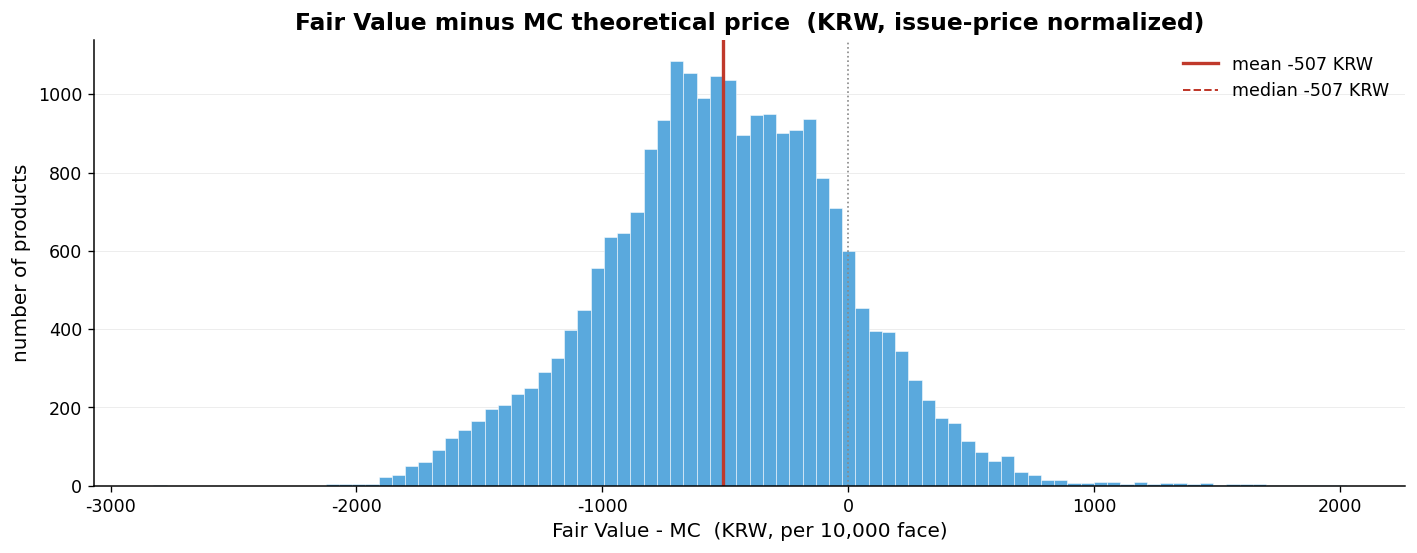

MC 평균 9,818원 | 공정가치 평균 9,311원
(공정가치 − MC) 평균 -507 | 중앙값 -507 | 표준편차 494


In [5]:
from util import plot as _plot   # 학술 rcParams (상/우 spine 제거 등)
import matplotlib.pyplot as plt

diff = df["fair_minus_mc_krw"].dropna()
fig, ax = plt.subplots(figsize=(12, 4.8))   # PPT 콘텐츠 밴드에 맞춤
ax.hist(diff, bins=90, color="#5aa9dd", edgecolor="white", linewidth=.3)
ax.axvline(diff.mean(), color="#c0392b", lw=2, label=f"mean {diff.mean():,.0f} KRW")
ax.axvline(diff.median(), color="#c0392b", lw=1.2, ls="--", label=f"median {diff.median():,.0f} KRW")
ax.axvline(0, color="#888", lw=1, ls=":")
ax.set_xlabel("Fair Value - MC  (KRW, per 10,000 face)")
ax.set_ylabel("number of products")
ax.set_title("Fair Value minus MC theoretical price  (KRW, issue-price normalized)")
ax.grid(axis="y", color="#dddddd", lw=0.5, alpha=0.6)
ax.legend(); fig.tight_layout()
fig.savefig(fm.image("fair_minus_mc_hist"), dpi=400, bbox_inches="tight", transparent=True); plt.show()
print(f"MC 평균 {df['mc_krw'].mean():,.0f}원 | 공정가치 평균 {df['fair_krw'].mean():,.0f}원")
print(f"(공정가치 − MC) 평균 {diff.mean():,.0f} | 중앙값 {diff.median():,.0f} | 표준편차 {diff.std():,.0f}")

## 가격 구간별 (공정가치 − MC) 오차

공정가치 6분위 구간별 `(공정가치 − MC)` 오차와 MAPE. 무보정 MC는 **저가(위험) 구간을 크게 과대평가**(오차 음수·MAPE↑)하고 고가(안전) 구간으로 갈수록 오차가 작아진다 — 역사변동성이 하방 스큐를 못 담는 구조적 편향. (`mc_k`는 무보정이라 전 구간 1.0.)

                   n  fair_mean  mc_mean  err_mean_KRW  err_median_KRW  MAPE_pct  k_mean
price_seg                                                                               
(0.703, 0.883]  3859       0.85     0.95       -992.51        -1128.49     12.48     1.0
(0.883, 0.912]  3858       0.90     0.97       -725.25         -825.46      8.70     1.0
(0.912, 0.936]  3859       0.92     0.99       -615.12         -703.12      7.06     1.0
(0.936, 0.958]  3858       0.95     0.99       -441.82         -519.20      5.10     1.0
(0.958, 0.98]   3858       0.97     0.99       -256.88         -309.23      3.39     1.0
(0.98, 1.05]    3859       1.00     1.00        -10.34          -52.81      1.94     1.0


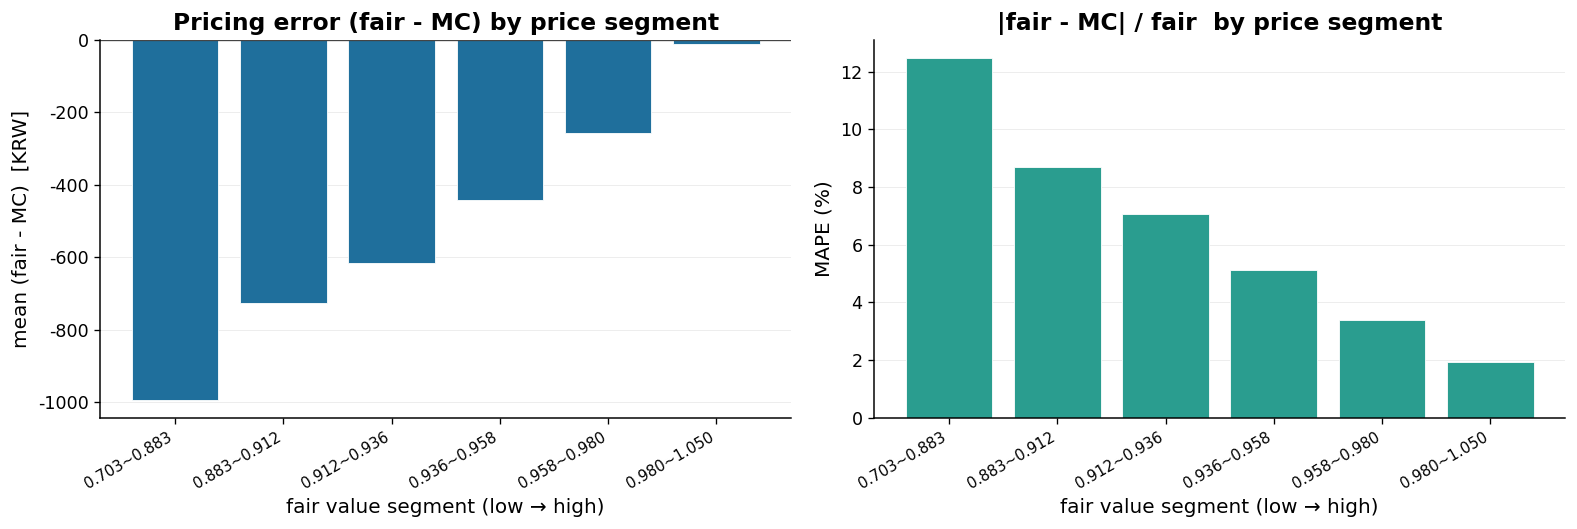

saved -> mae_err_by_price_seg.png


In [6]:
from util import plot as _plot   # 학술 rcParams
FACE = 10000
d2 = df.dropna(subset=["fair", "mc"]).copy()
d2["err_krw"] = (d2["fair"] - d2["mc"]) * FACE
d2["ape_pct"] = (d2["fair"] - d2["mc"]).abs() / d2["fair"].abs() * 100
d2["price_seg"] = pd.qcut(d2["fair"], 6)
g = d2.groupby("price_seg", observed=True).agg(
    n=("err_krw", "size"), fair_mean=("fair", "mean"), mc_mean=("mc", "mean"),
    err_mean_KRW=("err_krw", "mean"), err_median_KRW=("err_krw", "median"),
    MAPE_pct=("ape_pct", "mean"), k_mean=("mc_k", "mean"))
print(g.round(2).to_string())

xs = np.arange(len(g)); xl = [f"{iv.left:.3f}~{iv.right:.3f}" for iv in g.index]
fig, ax = plt.subplots(1, 2, figsize=(13.333, 4.6))   # PPT 콘텐츠 밴드
ax[0].bar(xs, g["err_mean_KRW"].values, color=np.where(g["err_mean_KRW"].values > 0, "#e07a5f", "#1f6f9c"),
          edgecolor="white", linewidth=0.5)
ax[0].axhline(0, color="#444", lw=.8)
ax[0].set_xticks(xs); ax[0].set_xticklabels(xl, rotation=30, fontsize=9, ha="right")
ax[0].set_ylabel("mean (fair - MC)  [KRW]"); ax[0].set_xlabel("fair value segment (low → high)")
ax[0].set_title("Pricing error (fair - MC) by price segment")
ax[0].grid(axis="y", color="#dddddd", lw=0.5, alpha=0.6)
ax[1].bar(xs, g["MAPE_pct"].values, color="#2a9d8f", edgecolor="white", linewidth=0.5)
ax[1].set_xticks(xs); ax[1].set_xticklabels(xl, rotation=30, fontsize=9, ha="right")
ax[1].set_ylabel("MAPE (%)"); ax[1].set_xlabel("fair value segment (low → high)")
ax[1].set_title("|fair - MC| / fair  by price segment")
ax[1].grid(axis="y", color="#dddddd", lw=0.5, alpha=0.6)
fig.tight_layout()
fig.savefig(fm.image("mae_err_by_price_seg"), dpi=400, bbox_inches="tight", transparent=True); plt.show()
print("saved ->", fm.image("mae_err_by_price_seg").name)